In [1]:
## RUN THIS FIRST WHEN ON COLAB (uncomment the lines below). Skip entirely when running locally.
# Google Drive is mounted in the setup cell further down, so no need to mount it here.

# Clone the repository
!git clone https://github.com/benpsutton/water_hyacinth_code.git

# Change into the repo
%cd /content/water_hyacinth_code/

# Install extra packages (if needed)
!pip install torchmetrics kornia optuna

Cloning into 'water_hyacinth_code'...
remote: Enumerating objects: 565, done.
remote: Counting objects: 100% (565/565), done.
remote: Compressing objects: 100% (329/329), done.
remote: Total 565 (delta 352), reused 429 (delta 224), pack-reused 0 (from 0)
Receiving objects: 100% (565/565), 12.22 MiB | 12.32 MiB/s, done.
Resolving deltas: 100% (352/352), done.
/content/water_hyacinth_code
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 134.2 MB/s eta 0:00:00


In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchmetrics
import kornia.augmentation as K
import pandas as pd
from statistics import median
import optuna
import sys

In [3]:
# --- Environment detection & paths ---
# Runs unchanged on both local (VSCode/Jupyter) and Colab.
#   PROJECT_ROOT -> where code + input data live (read from)
#   OUTPUT_ROOT  -> where results are saved (written to). On Colab this is Google Drive,
#                   so plots/CSVs/models persist after the runtime disconnects.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/water_hyacinth_code")                  # the cloned repo
    OUTPUT_ROOT = Path("/content/drive/MyDrive/Dissertation")    # persists in Drive
else:
    PROJECT_ROOT = Path().resolve().parent                              # notebooks/ -> repo root
    OUTPUT_ROOT = PROJECT_ROOT                                          # save in-repo, as before

# Create output dirs up front (plot_loss_curve / to_csv don't make them themselves)
(OUTPUT_ROOT / "outputs" / "plots" / "loss_curves").mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / "outputs" / "CNN_outputs" / "models").mkdir(parents=True, exist_ok=True)

datetime_now = datetime.datetime.now()
date = datetime_now.strftime("%Y-%m-%d")

SEED = 42
torch.manual_seed(SEED)

print(f"IN_COLAB:     {IN_COLAB}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"OUTPUT_ROOT:  {OUTPUT_ROOT}")

Mounted at /content/drive
IN_COLAB:     True
PROJECT_ROOT: /content/water_hyacinth_code
OUTPUT_ROOT:  /content/drive/MyDrive/Dissertation


In [4]:
sys.path.append(str(PROJECT_ROOT / "src"))

from model_utils import load_patch_dict_as_tensor, buildCNN_2xVGG, predict_on_test_region, train_for_one_epoch, val_for_one_epoch, load_dataset, record_epoch, record_inner_loop_best_state, record_outer_loop_mterics
from plotting import plot_loss_curve

In [5]:
# Load patches with specified size

patch_size = 15

patches_path = OUTPUT_ROOT / f"outputs/{patch_size}px_patches" / f"combined_{patch_size}px_patches.geojson"

with open(patches_path, "r") as f:
    patches_dict = json.load(f)


In [6]:

# # --- Device selection ---
# # Colab (with a GPU runtime: Runtime > Change runtime type > GPU):
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Apple Silicon (M1/M2/M3/M4), using the Metal Performance Shaders backend:
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Portable version that works on either without editing — checks cuda, then mps, then falls back to cpu:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

aug = K.AugmentationSequential(
    K.RandomRotation(degrees = 90.0, p =0.5),
    K.RandomHorizontalFlip(p= 0.25),
    K.RandomVerticalFlip(p= 0.25),
    data_keys= ['input']).to(device)

# metrics - use torchmetrics to make a metric collection that is a dictionary of metrics

metrics = torchmetrics.MetricCollection({
    "accuracy": torchmetrics.classification.BinaryAccuracy(),
    "f1": torchmetrics.classification.BinaryF1Score(),
    "precision": torchmetrics.classification.BinaryPrecision(),
    "recall": torchmetrics.classification.BinaryRecall(),
    "auroc": torchmetrics.classification.BinaryAUROC()
}).to(device)


# Nested loop without hyperparameter tuning

In [ ]:
# # Create a nested loop without doing hyperparameter tuning

# band_list = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

# patches, labels, locations, class_int, label_id = load_patch_dict_as_tensor(patches_dict, band_list= band_list)
# del patches_dict

# input_channels = len(band_list)

# num_epochs = 2
# best_val_loss = float("inf")
# patience = 10
# epochs_no_improve = 0
# best_state = None
# best_val_metrics = None
# best_epoch = None


# list_of_run_histories = [] # will store per-epoch training and validation metrics of EVERY run for later plotting
# list_of_predicition_dfs = [] # will store predictions and labels for each of the outer fold test regions for confusion matrix
# list_of_inner_best_state_metrics = [] # will store the training vand validation losses and other metrics for the best model for each inner fold.

# outer_metrics_dict= {"run_ID": [], "patch_size": [], "test_region": [], "epochs_trained": [], "test_loss": [], "test_accuracy": [], "test_f1": [], "test_precision": [],
#                      "test_recall": [], "test_auroc": [], "train_loss": [], "train_accuracy": [], "train_f1": [], "train_precision": [], "train_recall": [], "train_auroc": []}
# # will store final epoch training loss, and testing loss and other metrics for the outer folds

# location_list = ["Hartbeespoort", "Rodman", "Mula", "Inle", "Vembanad", "Valsequillo", "RawaPening", "Winam"]

# for location in location_list:

#     test_region = location
#     remaining_regions = [loc for loc in location_list if loc != location]
#     test_abrv = test_region[0:3]
#     # print(test_abrv)

#     # Need a fresh best_state_dict for each outer fold so can get final metrics of the inner fold runs.
#     inner_best_state_dict= {"run_ID": [], "patch_size":[], "test_region": [], "val_region": [], "train_loss": [], "val_loss": [], "epoch_stopped": [],
#                   "val_accuracy": [], "val_f1": [], "val_precision": [], "val_recall": [], "val_auroc":[], }

#     for region in remaining_regions:

#         val_region = region
#         training_regions = [loc for loc in remaining_regions if loc != region]
#         val_abrv = val_region[0:3]

#         run_ID = f"T-{test_abrv}_V-{val_abrv}_{patch_size}px_{date}"


#         model = buildCNN_2xVGG(input_channels= input_channels, dropout = 0.3)
#         model = model.to(device)
#         criterion = nn.BCEWithLogitsLoss()
#         optimizer = optim.Adam(model.parameters(), lr = 1e-3, weight_decay = 1e-4)
#         # was: scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
#         scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5) # reduces the step size by half every 5 epochs/

#         num_epochs = 100
#         best_val_loss = float("inf")
#         patience = 10
#         epochs_no_improve = 0
#         best_state = None
#         best_val_metrics = None
#         best_epoch = None


#         # Create history_dict for each run, with values for each epoch, that will then be contanated into a long dataframe for plotting loss_curves / analysis
#         history_dict = {"test_region": [], "val_region": [],"run_ID": [], "patch_size":[], "loop":[], "epoch":[], "train_loss": [], "val_loss": [], "val_accuracy": [], "val_f1": [], "val_precision": [], "val_recall": [], "val_auroc":[],
#                         "train_accuracy":[],"train_f1":[], "train_precision":[], "train_recall":[], "train_auroc":[]
#                         }

#         # train_data, val_data, train laoder, val loader
#         #-------------------------------------------------------
#         test_mask = locations == test_region
#         val_mask = locations == val_region

#         train_mask = ~test_mask & ~ val_mask

#         train_patches, train_labels = patches[train_mask], labels[train_mask]
#         val_patches, val_labels = patches[val_mask], labels[val_mask]
#         # test_patches, test_labels, test_labels_ids = patches[test_mask], labels[test_mask], label_id[test_mask]


#         mean = train_patches.mean(dim= (0,2,3)) # will average over the 0,2,3 axes and keep the 1 axis (channels / bands) separate. output shape (C,)
#         std = train_patches.std(dim = (0,2,3))

#         train_loader = load_dataset(patches=train_patches,
#                                     labels= train_labels,
#                                     mean= mean,
#                                     std = std,
#                                     batch_size= 32,
#                                     shuffle= True)

#         val_loader = load_dataset(patches = val_patches,
#                                   labels= val_labels,
#                                   mean= mean,
#                                   std= std,
#                                   shuffle = False,
#                                   batch_size= 32
#                                   )

#         for epoch in range(num_epochs):

#             train_loss,train_metrics = train_for_one_epoch(model, train_loader, device, aug, optimizer, metrics, criterion)
#             val_loss, val_metrics = val_for_one_epoch(model, val_loader, metrics, device, criterion)

#             # Save metrics for epoch to history dict
#             record_epoch(history_dict= history_dict, run_ID=run_ID, patch_size = patch_size, loop = "inner", epoch=epoch, test_region=test_region, val_region=val_region,
#                          train_loss=train_loss, val_loss= val_loss, train_metrics= train_metrics, val_metrics=val_metrics )

#             scheduler.step()

#             print(f"Epoch {epoch+1}/100 | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} "
#                 f"| val_f1: {val_metrics['f1']:.4f} | val_acc: {val_metrics['accuracy']:.4f}")

#             # Early stopping

#             if val_loss < best_val_loss:
#                 best_val_loss = val_loss
#                 best_train_loss = train_loss
#                 best_val_metrics = val_metrics
#                 best_epoch = epoch
#                 epochs_no_improve = 0
#                 best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
#             else:
#                 epochs_no_improve +=1
#                 if epochs_no_improve >= patience:
#                     print(f"Early stopping at epcoch: {epoch+1}")
#                     break

#         # model.load_state_dict(best_state)

#         loss_curve_fp = OUTPUT_ROOT / "outputs/plots/loss_curves" / f"{run_ID}.png"
#         plot_loss_curve(history_dict, loss_curve_fp)

#         print(run_ID)
#         print(f"Best epoch: {best_epoch+1} | val_loss: {best_val_loss:.4f} | val_metrics: {best_val_metrics}")

#         # Append this run's history dict to list for later concatenation.
#         list_of_run_histories.append(history_dict)

#         # Save metrics for the best state after training / early stopping

#         record_inner_loop_best_state(inner_best_state_dict, run_ID, patch_size, best_epoch, test_region, val_region, train_loss, best_val_loss, best_val_metrics)

#     list_of_inner_best_state_metrics.append(inner_best_state_dict)

#     # -------------------------
#     # Outer fold -> train on all remaining regions using median number of epochs from inner fold
#     #---------------------------------------------------------------------------------------------
#     history_dict = {"run_ID": [], "test_region": [], "patch_size":[], "loop":[], "epoch":[], "train_loss": [], "train_accuracy":[],"train_f1":[], "train_precision":[], "train_recall":[], "train_auroc":[]
#                         }

#     test_mask = locations == test_region
#     remaining_mask = locations != test_region

#     run_ID = f"Test_{test_abrv}_outer_{patch_size}px_{date}"

#     remaining_patches = patches[remaining_mask]
#     remaining_mean = remaining_patches.mean(dim= (0,2,3))
#     remaining_std =  remaining_patches.std(dim= (0,2,3))

#     test_patches = patches[test_mask]

#     remaining_labels = labels[remaining_mask]
#     test_labels = labels[test_mask]
#     test_label_ids = label_id[test_mask]
#     test_class_int = class_int[test_mask]

#     remaining_loader = load_dataset(patches=remaining_patches,
#                                     labels= remaining_labels,
#                                     mean= remaining_mean,
#                                     std= remaining_std,
#                                     shuffle = True,
#                                     batch_size = 32
#                                     )


#     test_loader = load_dataset(patches=test_patches,
#                                labels = test_labels,
#                                mean = remaining_mean,
#                                std = remaining_std,
#                                shuffle= False,
#                                batch_size= 32
#                                )

#     model = buildCNN_2xVGG(input_channels= input_channels, dropout = 0.3)
#     model = model.to(device)
#     criterion = nn.BCEWithLogitsLoss()
#     optimizer = optim.Adam(model.parameters(), lr = 1e-3, weight_decay = 1e-4)

#     scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

#     epochs_stopped = list(inner_best_state_dict["epoch_stopped"])
#     median_epoch = int(median(epochs_stopped))

#     for epoch in range(median_epoch):
#         train_loss, train_metrics = train_for_one_epoch(model, remaining_loader, device, aug, optimizer, metrics, criterion)

#         scheduler.step()

#         print(f"Epoch {epoch+1}/100 | train_loss: {train_loss:.4f}")

#         # save the per epoch metrics so can plot loss curve later

#         record_epoch(history_dict= history_dict, run_ID=run_ID, patch_size = patch_size, loop = "outer", epoch=epoch, test_region=test_region,
#                          train_loss=train_loss, train_metrics= train_metrics)

#         loss_curve_fp = OUTPUT_ROOT / "outputs/plots/loss_curves" / f"{run_ID}.png"

#     # Append trainining history dict
#     list_of_run_histories.append(history_dict)

#     # Use model to predict on the held-out test region, save preds for creating confusion matrix.

#     test_loss, test_metrics, preds_tensor, logits = predict_on_test_region(model, test_loader, metrics, device, criterion)

#     loss_curve_fp = OUTPUT_ROOT / "outputs/plots/loss_curves" / f"{run_ID}.png"

#     plot_loss_curve(history_dict, loss_curve_fp)

#     record_outer_loop_mterics(outer_metrics_dict, run_ID, patch_size, test_region, median_epoch, test_loss, train_loss, test_metrics, train_metrics)


# # Need to put together the preds with labels etc

#     preds_array = preds_tensor.detach().squeeze(1).cpu().numpy()
#     labels_array = test_labels.detach().squeeze(1).numpy()

#     prediction_df = pd.DataFrame({
#         "labels": labels_array,
#         "predicted": preds_array,
#         "class_int": test_class_int,
#         "test_region": test_region,
#         "run_id": run_ID
#     })

#     list_of_predicition_dfs.append(prediction_df)

#     # save trained models and the relevant parameters for each outer fold?

#     checkpoint = {
#         "run_ID": run_ID,
#         "test_region": test_region,
#         "model_state_dict": model.state_dict(),
#         "mean": remaining_mean,
#         "std": remaining_std,
#         "band_list": band_list,
#         "median_epoch": median_epoch,
#         "hyperparams": {"lr": 1e-3, "weight_decay": 1e-4, "dropout": 0.3, "batch_size": 32},
#     }
#     model_fp = OUTPUT_ROOT / "outputs" / "CNN_outputs" / "models" / f"{run_ID}.pt"
#     model_fp.parent.mkdir(parents=True, exist_ok=True)
#     torch.save(checkpoint, model_fp)

# #----------------------------------------------------------------------------------
# # After loops
# # Concat the the prediciton_dfs

# predictions = pd.concat(list_of_predicition_dfs,axis=0)

# # Need to combine the history dicts into a data frame
# history_df = pd.concat([pd.DataFrame(h) for h in list_of_run_histories], ignore_index= True)

# run_history_fp = OUTPUT_ROOT / "outputs" / "CNN_outputs" / f"training_run_history_{patch_size}px_{date}.csv"
# history_df.to_csv(run_history_fp)

# # save the outer metrics as data frame

# outer_metrics_df =pd.DataFrame(outer_metrics_dict)

# outer_metrics_fp = OUTPUT_ROOT / "outputs" / "CNN_outputs" / f"Outer_fold_metrics_{patch_size}px_{date}.csv"

# outer_metrics_df.to_csv(outer_metrics_fp)
# # save the best inner metrics as dataframe for each fold

# inner_metrics_df = pd.concat([pd.DataFrame(h) for h in list_of_inner_best_state_metrics], ignore_index= True)

# inner_metrics_fp = OUTPUT_ROOT / "outputs" / "CNN_outputs" / f"Inner_fold_best_state_metrics_{patch_size}px_{date}.csv"
# inner_metrics_df.to_csv(inner_metrics_fp)



In [7]:
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# Nested Loop with Optuna hyperparameter tuning on the inner fold

Returned patch tensor shape: torch.Size([16189, 10, 15, 15])
Returned label tensor shape: torch.Size([16189, 1])
Returned locations array: (16189,)
Returned class_int array: (16189,)
Returned label_id array: (16189,)
Bands used: ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']


[I 2026-07-16 17:13:04,763] A new study created in memory with name: no-name-c16c1e93-d092-4517-9efc-c9f0571ef4b6
/Users/bensutton/Projects/dissertation-code/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/100 | train_loss: 0.3331 | val_loss: 0.4839 | val_f1: 0.9096 | val_acc: 0.9025
Epoch 2/100 | train_loss: 0.2141 | val_loss: 0.3975 | val_f1: 0.8756 | val_acc: 0.8717
Epoch 1/100 | train_loss: 0.3599 | val_loss: 0.9232 | val_f1: 0.3009 | val_acc: 0.5874
Epoch 2/100 | train_loss: 0.2101 | val_loss: 0.4860 | val_f1: 0.7399 | val_acc: 0.7886
Epoch 1/100 | train_loss: 0.3578 | val_loss: 0.2947 | val_f1: 0.9151 | val_acc: 0.9130
Epoch 2/100 | train_loss: 0.2511 | val_loss: 0.2220 | val_f1: 0.9042 | val_acc: 0.9090
Epoch 1/100 | train_loss: 0.3632 | val_loss: 0.2023 | val_f1: 0.9391 | val_acc: 0.9406
Epoch 2/100 | train_loss: 0.2390 | val_loss: 0.1343 | val_f1: 0.9668 | val_acc: 0.9665
Epoch 1/100 | train_loss: 0.3576 | val_loss: 0.2918 | val_f1: 0.8762 | val_acc: 0.8799
Epoch 2/100 | train_loss: 0.2258 | val_loss: 0.2133 | val_f1: 0.9292 | val_acc: 0.9284
Epoch 1/100 | train_loss: 0.3687 | val_loss: 0.1447 | val_f1: 0.9544 | val_acc: 0.9530
Epoch 2/100 | train_loss: 0.2411 | val_loss

[I 2026-07-16 17:14:54,722] Trial 0 finished with value: 0.285504733339857 and parameters: {'lr': 0.005874505647206538, 'dropout': 0.13030461103514399}. Best is trial 0 with value: 0.285504733339857.


Epoch 2/100 | train_loss: 0.2258 | val_loss: 0.4209 | val_f1: 0.8760 | val_acc: 0.8669
Epoch 1/100 | train_loss: 0.3654 | val_loss: 0.4486 | val_f1: 0.8163 | val_acc: 0.8164
Epoch 2/100 | train_loss: 0.2391 | val_loss: 0.3376 | val_f1: 0.9033 | val_acc: 0.9001
Epoch 1/100 | train_loss: 0.3530 | val_loss: 0.5068 | val_f1: 0.6671 | val_acc: 0.7428
Epoch 2/100 | train_loss: 0.2199 | val_loss: 0.7860 | val_f1: 0.2519 | val_acc: 0.5700
Epoch 1/100 | train_loss: 0.3727 | val_loss: 0.3618 | val_f1: 0.8201 | val_acc: 0.8350
Epoch 2/100 | train_loss: 0.2598 | val_loss: 0.2278 | val_f1: 0.8963 | val_acc: 0.8965
Epoch 1/100 | train_loss: 0.3858 | val_loss: 0.3857 | val_f1: 0.8237 | val_acc: 0.8412
Epoch 2/100 | train_loss: 0.2589 | val_loss: 0.3437 | val_f1: 0.8579 | val_acc: 0.8701
Epoch 1/100 | train_loss: 0.3777 | val_loss: 0.2159 | val_f1: 0.9206 | val_acc: 0.9206
Epoch 2/100 | train_loss: 0.2614 | val_loss: 0.2026 | val_f1: 0.9381 | val_acc: 0.9368
Epoch 1/100 | train_loss: 0.3909 | val_loss

...

Epoch 2/100 | train_loss: 0.2066 | val_loss: 0.4470 | val_f1: 0.8288 | val_acc: 0.8249
Epoch 1/100 | train_loss: 0.2887 | val_loss: 0.3993 | val_f1: 0.8823 | val_acc: 0.8737
Epoch 2/100 | train_loss: 0.1869 | val_loss: 0.3518 | val_f1: 0.8680 | val_acc: 0.8692
Epoch 1/100 | train_loss: 0.2781 | val_loss: 0.5010 | val_f1: 0.6612 | val_acc: 0.7389
Epoch 2/100 | train_loss: 0.1736 | val_loss: 0.4981 | val_f1: 0.6437 | val_acc: 0.7307
Epoch 1/100 | train_loss: 0.3231 | val_loss: 0.1764 | val_f1: 0.9610 | val_acc: 0.9610
Epoch 2/100 | train_loss: 0.2170 | val_loss: 0.1892 | val_f1: 0.9173 | val_acc: 0.9165
Epoch 1/100 | train_loss: 0.3260 | val_loss: 0.2336 | val_f1: 0.9121 | val_acc: 0.9156
Epoch 2/100 | train_loss: 0.2102 | val_loss: 0.1506 | val_f1: 0.9498 | val_acc: 0.9500
Epoch 1/100 | train_loss: 0.3248 | val_loss: 0.2446 | val_f1: 0.9066 | val_acc: 0.9059
Epoch 2/100 | train_loss: 0.2144 | val_loss: 0.2645 | val_f1: 0.8990 | val_acc: 0.9039
Epoch 1/100 | train_loss: 0.3185 | val_loss

[I 2026-07-16 17:38:21,331] Trial 13 finished with value: 0.2819706093804603 and parameters: {'lr': 0.0011987906319231513, 'dropout': 0.21209243013796542}. Best is trial 8 with value: 0.24399852291583993.


Epoch 2/100 | train_loss: 0.2122 | val_loss: 0.3836 | val_f1: 0.8560 | val_acc: 0.8519
Epoch 1/100 | train_loss: 0.3181 | val_loss: 0.4212 | val_f1: 0.8209 | val_acc: 0.8320
Epoch 2/100 | train_loss: 0.1968 | val_loss: 0.3914 | val_f1: 0.8442 | val_acc: 0.8482
Epoch 1/100 | train_loss: 0.3123 | val_loss: 0.5775 | val_f1: 0.5195 | val_acc: 0.6723
Epoch 2/100 | train_loss: 0.1915 | val_loss: 0.6072 | val_f1: 0.5452 | val_acc: 0.6844
Epoch 1/100 | train_loss: 0.3344 | val_loss: 0.2239 | val_f1: 0.9062 | val_acc: 0.9070
Epoch 2/100 | train_loss: 0.2273 | val_loss: 0.2780 | val_f1: 0.8425 | val_acc: 0.8155
Epoch 1/100 | train_loss: 0.3299 | val_loss: 0.2166 | val_f1: 0.9152 | val_acc: 0.9161
Epoch 2/100 | train_loss: 0.2216 | val_loss: 0.1989 | val_f1: 0.9268 | val_acc: 0.9266
Epoch 1/100 | train_loss: 0.3424 | val_loss: 0.2118 | val_f1: 0.9259 | val_acc: 0.9235
Epoch 2/100 | train_loss: 0.2296 | val_loss: 0.1469 | val_f1: 0.9475 | val_acc: 0.9471
Epoch 1/100 | train_loss: 0.3507 | val_loss

[I 2026-07-16 17:40:09,858] Trial 14 finished with value: 0.2916208099402723 and parameters: {'lr': 0.00030656738902247975, 'dropout': 0.3406936996950145}. Best is trial 8 with value: 0.24399852291583993.


Epoch 2/100 | train_loss: 0.2067 | val_loss: 0.4070 | val_f1: 0.8500 | val_acc: 0.8499


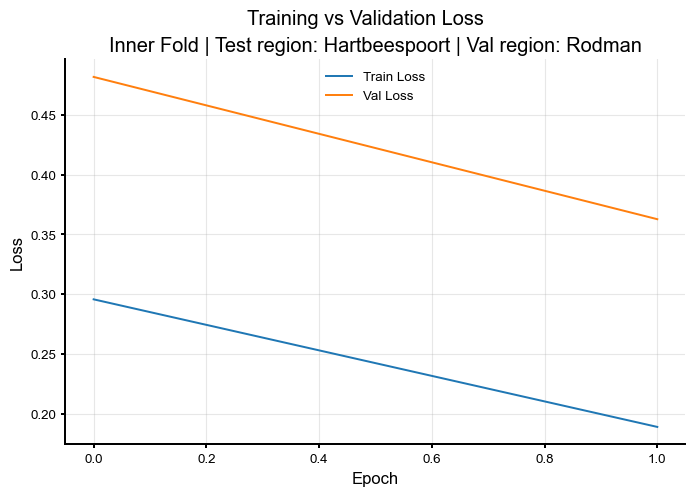

T-Har_V-Rod_15px_2026-07-16
Test region: Hartbeespoort, Val region: Rodman


KeyError: 'train_f1'

In [ ]:
# Define an objective function in the outer loop which wraps the inner loop

band_list = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

patches, labels, locations, class_int, label_id = load_patch_dict_as_tensor(patches_dict, band_list= band_list)
del patches_dict

input_channels = len(band_list)

num_epochs = 100
best_val_loss = float("inf")
patience = 10
epochs_no_improve = 0
best_state = None
best_val_metrics = None
best_epoch = None


list_of_run_histories = [] # will store per-epoch training and validation metrics of all best trial and test runs for later plotting
list_of_predicition_dfs = [] # will store predictions and labels for each of the outer fold test regions for confusion matrix
list_of_inner_best_state_metrics = [] # will store the training vand validation losses and other metrics for the best model for each inner fold.

outer_metrics_dict= {"run_ID": [], "patch_size": [], "test_region": [], "epochs_trained": [], "test_loss": [], "test_accuracy": [], "test_f1": [], "test_precision": [],
                     "test_recall": [], "test_auroc": [], "train_loss": [], "train_accuracy": [], "train_f1": [], "train_precision": [], "train_recall": [], "train_auroc": []}
# will store final epoch training loss, and testing loss and other metrics for the outer folds

location_list = ["Hartbeespoort", "Rodman", "Mula", "Inle", "Vembanad", "Valsequillo", "RawaPening", "Winam"]

for location in location_list:

    test_region = location
    remaining_regions = [loc for loc in location_list if loc != location]
    test_abrv = test_region[0:3]
    # print(test_abrv)



    def objective(trial):

        # Learning rate
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log = True)
        # dropout
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        # weight decay
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log = True)

        inner_val_losses = [] # by optuna to asses perfmance at each trial
        inner_f1_scores = [] # If want to select optuna trials based on f1 score instead
        inner_best_epochs = [] # which epoch numbers is best for each run in the trial -> use mean to set epochs for training on test
        fold_metrics = [] # will be added to the user attributes for each trial, then can easity access the metrics of the best_trial
        fold_histories = [] # to append the training histry_dict for each fold in the trial to allow plotting of the loss curve for thr best trial

        for region in remaining_regions:

            val_region = region
            training_regions = [loc for loc in remaining_regions if loc != region]
            val_abrv = val_region[0:3]

            run_ID = f"T-{test_abrv}_V-{val_abrv}_{patch_size}px_{date}"

            model = buildCNN_2xVGG(input_channels= input_channels, dropout = dropout)
            model = model.to(device)
            criterion = nn.BCEWithLogitsLoss()
            optimizer = optim.Adam(model.parameters(), lr = lr, weight_decay = weight_decay)
            # was: scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
            scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5) # reduces the step size by half every 5 epochs/

            num_epochs = 100
            best_val_loss = float("inf")
            patience = 10
            epochs_no_improve = 0
            best_state = None
            best_val_metrics = None
            best_epoch = None
            best_train_metrics = None


            # Create history_dict for each run, with values for each epoch, that will then be contanated into a long dataframe for plotting loss_curves / analysis
            history_dict = {"test_region": [], "val_region": [],"run_ID": [], "patch_size":[], "loop":[], "epoch":[], "train_loss": [], "val_loss": [], "val_accuracy": [], "val_f1": [], "val_precision": [], "val_recall": [], "val_auroc":[],
                            "train_accuracy":[],"train_f1":[], "train_precision":[], "train_recall":[], "train_auroc":[]
                            }

            # train_data, val_data, train laoder, val loader
            #-------------------------------------------------------
            test_mask = locations == test_region
            val_mask = locations == val_region

            train_mask = ~test_mask & ~ val_mask

            train_patches, train_labels = patches[train_mask], labels[train_mask]
            val_patches, val_labels = patches[val_mask], labels[val_mask]
            # test_patches, test_labels, test_labels_ids = patches[test_mask], labels[test_mask], label_id[test_mask]


            mean = train_patches.mean(dim= (0,2,3)) # will average over the 0,2,3 axes and keep the 1 axis (channels / bands) separate. output shape (C,)
            std = train_patches.std(dim = (0,2,3))

            train_loader = load_dataset(patches=train_patches,
                                        labels= train_labels,
                                        mean= mean,
                                        std = std,
                                        batch_size= 128,
                                        shuffle= True)

            val_loader = load_dataset(patches = val_patches,
                                    labels= val_labels,
                                    mean= mean,
                                    std= std,
                                    shuffle = False,
                                    batch_size= 128
                                    )

            for epoch in range(num_epochs):

                train_loss, train_metrics = train_for_one_epoch(model, train_loader, device, aug, optimizer, metrics, criterion)
                val_loss, val_metrics = val_for_one_epoch(model, val_loader, metrics, device, criterion)

                # Save metrics for epoch to history dict
                record_epoch(history_dict= history_dict, run_ID=run_ID, patch_size = patch_size, loop = "inner", epoch=epoch, test_region=test_region, val_region=val_region,
                            train_loss=train_loss, val_loss= val_loss, train_metrics= train_metrics, val_metrics=val_metrics )

                scheduler.step()

                print(f"Epoch {epoch+1}/100 | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_f1: {val_metrics['f1']:.4f}"
                    f"| val_acc: {val_metrics['accuracy']:.4f}")

                # Early stopping

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_train_loss = train_loss
                    best_val_metrics = val_metrics
                    best_train_metrics = train_metrics
                    best_epoch = epoch + 1 # Need to change to 1-based number, so can be recorded and calculate median for outer loop.
                    epochs_no_improve = 0
                else:
                    epochs_no_improve +=1
                    if epochs_no_improve >= patience:
                        print(f"Early stopping at epcoch: {epoch+1}")
                        break
            fold_histories.append(history_dict)


            inner_val_losses.append(best_val_loss)
            inner_f1_scores.append(best_val_metrics["f1"])
            inner_best_epochs.append(best_epoch)

            fold_metrics.append({
                "test_region": test_region,
                "val_region": val_region,
                "epoch_stopped": best_epoch,
                "train_loss": best_train_loss,
                "val_loss": best_val_loss,
                "val_metrics": best_val_metrics,
                "train_metrics": best_train_metrics
                })



        trial.set_user_attr("epochs", inner_best_epochs)
        trial.set_user_attr("fold_metrics", fold_metrics)
        trial.set_user_attr("fold_histories", fold_histories)

        return float(np.mean(inner_f1_scores)) # returns the mean f1 for each trial, previously had this as inner_valloss with create_stufy(ditection = "minimize")

    sampler = optuna.samplers.TPESampler(n_startup_trials=5, seed=42) # 5 trials with radom params before tpe
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials = 15)

    best_params = study.best_trial.params # a dict of the parameters and the best values. Values from best trial chosed based on mean validation loss across fold in the trial (at best epoch)
    median_epoch = int(np.median(study.best_trial.user_attrs["epochs"])) # returns the median value of the epoch number at early stopping of the folds in the best trial.

    # Need a fresh best_state_dict for each outer fold, to save the per-fold metrics from the winning trial
    inner_best_state_dict= {"run_ID": [], "patch_size":[], "test_region": [], "val_region": [], "train_loss": [], "val_loss": [], "epoch_stopped": [],
                  "val_accuracy": [], "val_f1": [], "val_precision": [], "val_recall": [], "val_auroc":[],"train_accuracy": [], "train_f1": [], "train_precision": [], "train_recall": [], "train_auroc": [],
    "dropout": [], "lr": []}

    for record in study.best_trial.user_attrs["fold_metrics"]: # loops through the folds in the best_trial
        val_abrv = record["val_region"][0:3]
        run_ID = f"T-{test_abrv}_V-{val_abrv}_{patch_size}px_{date}"
        record_inner_loop_best_state(inner_best_state_dict= inner_best_state_dict,
                                     run_ID = run_ID,
                                     patch_size= patch_size,
                                     best_epoch= record["epoch_stopped"],
                                     test_region= test_region,
                                     val_region= record["val_region"],
                                     train_loss= record["train_loss"],
                                     best_val_loss= record["val_loss"],
                                     best_val_metrics= record["val_metrics"],
                                     best_train_metrics= record["train_metrics"],
                                     lr = best_params["lr"],
                                     dropout = best_params["dropout"]
                                     )


    list_of_inner_best_state_metrics.append(inner_best_state_dict) # save the best trial inner fold metrics to a list that can be concatenated later


    # plot the loss curves for the best trial fold, append to best trial list for later concatenation and saving

    best = study.best_trial
    for fold, record in zip(best.user_attrs["fold_histories"], best.user_attrs["fold_metrics"]):
        run_ID = fold["run_ID"][0] # run id is broadcast down the column for each epoch
        loss_curve_fp = OUTPUT_ROOT / "outputs/plots/loss_curves" / f"{run_ID}.png"
        plot_loss_curve(fold, loss_curve_fp)

        list_of_run_histories.append(fold)


        print(run_ID)
        print(f"Test region: {test_region}, Val region: {record['val_region']}")
        print(f"Best epoch: {record['epoch_stopped']} | val_loss: {record['val_loss']:.4f} | train_f1: {record['train_metrics']['f1']:.4f} val_f1: {record['val_metrics']['f1']:.4f}" )

    # Append this run's history dict to list for later concatenation.



    # -------------------------
    # Outer fold -> train on all remaining regions using median number of epochs from inner fold
    #---------------------------------------------------------------------------------------------
    history_dict = {"run_ID": [], "test_region": [], "patch_size":[], "loop":[], "epoch":[], "train_loss": [], "train_accuracy":[],"train_f1":[], "train_precision":[], "train_recall":[], "train_auroc":[]
                        }

    test_mask = locations == test_region
    remaining_mask = locations != test_region

    run_ID = f"Test_{test_abrv}_outer_{patch_size}px_{date}"

    remaining_patches = patches[remaining_mask]
    remaining_mean = remaining_patches.mean(dim= (0,2,3))
    remaining_std =  remaining_patches.std(dim= (0,2,3))

    test_patches = patches[test_mask]

    remaining_labels = labels[remaining_mask]
    test_labels = labels[test_mask]
    test_label_ids = label_id[test_mask]
    test_class_int = class_int[test_mask]

    remaining_loader = load_dataset(patches=remaining_patches,
                                    labels= remaining_labels,
                                    mean= remaining_mean,
                                    std= remaining_std,
                                    shuffle = True,
                                    batch_size = 128
                                    )


    test_loader = load_dataset(patches=test_patches,
                               labels = test_labels,
                               mean = remaining_mean,
                               std = remaining_std,
                               shuffle= False,
                               batch_size= 128
                               )

    model = buildCNN_2xVGG(input_channels= input_channels, dropout = best_params["dropout"])
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr = best_params["lr"], weight_decay = best_params["weight_decay"])

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    for epoch in range(median_epoch):
        train_loss, train_metrics = train_for_one_epoch(model, remaining_loader, device, aug, optimizer, metrics, criterion)

        scheduler.step()

        print(f"Epoch {epoch+1}/100 | train_loss: {train_loss:.4f}")

        # save the per epoch metrics so can plot loss curve later

        record_epoch(history_dict= history_dict, run_ID=run_ID, patch_size = patch_size, loop = "outer", epoch=epoch, test_region=test_region,
                         train_loss=train_loss, train_metrics= train_metrics)

        loss_curve_fp = OUTPUT_ROOT / "outputs/plots/loss_curves" / f"{run_ID}.png"

    # Append trainining history dict
    list_of_run_histories.append(history_dict)

    # Use model to predict on the held-out test region, save preds for creating confusion matrix.

    test_loss, test_metrics, preds_tensor, logits = predict_on_test_region(model, test_loader, metrics, device, criterion)

    loss_curve_fp = OUTPUT_ROOT / "outputs/plots/loss_curves" / f"{run_ID}.png"

    plot_loss_curve(history_dict, loss_curve_fp)

    record_outer_loop_mterics(outer_metrics_dict, run_ID, patch_size, test_region, median_epoch, test_loss, train_loss, test_metrics, train_metrics)


# Need to put together the preds with labels etc

    preds_array = preds_tensor.detach().squeeze(1).cpu().numpy()
    labels_array = test_labels.detach().squeeze(1).numpy()

    prediction_df = pd.DataFrame({
        "labels": labels_array,
        "predicted": preds_array,
        "class_int": test_class_int,
        "test_region": test_region,
        "run_id": run_ID
    })

    list_of_predicition_dfs.append(prediction_df)

    # save trained models and the relevant parameters for each outer fold?

    checkpoint = {
        "run_ID": run_ID,
        "test_region": test_region,
        "model_state_dict": model.state_dict(),
        "mean": remaining_mean,
        "std": remaining_std,
        "band_list": band_list,
        "median_epoch": median_epoch,
        "hyperparams": {"lr": best_params["lr"], "weight_decay": best_params["weight_decay"], "dropout": best_params["dropout"], "batch_size": 32},
    }
    model_fp = OUTPUT_ROOT / "outputs" / "CNN_outputs" / "models" / f"{run_ID}.pt"
    model_fp.parent.mkdir(parents=True, exist_ok=True)
    torch.save(checkpoint, model_fp)

#----------------------------------------------------------------------------------
# After loops
# Concat the the prediciton_dfs

predictions = pd.concat(list_of_predicition_dfs,axis=0)

# Need to combine the history dicts into a data frame
history_df = pd.concat([pd.DataFrame(h) for h in list_of_run_histories], ignore_index= True)

run_history_fp = OUTPUT_ROOT / "outputs" / "CNN_outputs" / f"training_run_history_{patch_size}px_{date}.csv"
history_df.to_csv(run_history_fp)

# save the outer metrics as data frame

outer_metrics_df =pd.DataFrame(outer_metrics_dict)

outer_metrics_fp = OUTPUT_ROOT / "outputs" / "CNN_outputs" / f"Outer_fold_metrics_{patch_size}px_{date}.csv"

outer_metrics_df.to_csv(outer_metrics_fp)
# save the best inner metrics as dataframe for each fold

inner_metrics_df = pd.concat([pd.DataFrame(h) for h in list_of_inner_best_state_metrics], ignore_index= True)

inner_metrics_fp = OUTPUT_ROOT / "outputs" / "CNN_outputs" / f"Inner_fold_best_state_metrics_{patch_size}px_{date}.csv"
inner_metrics_df.to_csv(inner_metrics_fp)



In [ ]:
print(list_of_run_histories[0].keys())

dict_keys(['test_region', 'val_region', 'run_ID', 'patch_size', 'loop', 'epoch', 'train_loss', 'val_loss', 'val_accuracy', 'val_f1', 'val_precision', 'val_recall', 'val_auroc', 'train_accuracy', 'train_f1', 'train_precision', 'train_recall', 'train_auroc'])


In [ ]:
df = pd.DataFrame(list_of_run_histories[0])

In [ ]:
df.head()

,test_region,val_region,run_ID,patch_size,loop,epoch,train_loss,val_loss,val_accuracy,val_f1,val_precision,val_recall,val_auroc,train_accuracy,train_f1,train_precision,train_recall,train_auroc
0,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-16,15,inner,1,0.295784,0.481665,0.832517,0.844687,0.788136,0.909980,0.894271,0.879488,0.878272,0.882688,0.873901,0.946921
1,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-16,15,inner,2,0.189160,0.362758,0.866308,0.866242,0.867517,0.864971,0.944063,0.932315,0.932029,0.931257,0.932802,0.976979
